# Solución: House Prices - Advanced Regression Techniques

## Objetivo
Predecir el precio de venta de casas (`SalePrice`) en Ames, Iowa usando técnicas de regresión múltiple y Machine Learning.

## Metodología
Seguiremos los 9 pasos establecidos en el examen:
1. Comprensión del problema
2. Exploración de los datos (EDA)
3. Limpieza de datos
4. Codificación de variables categóricas
5. Escalamiento/Normalización
6. Selección de variables relevantes
7. Construcción del modelo
8. Evaluación del modelo
9. Interpretación de resultados


In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


## Paso 1: Comprensión del problema

**Variable dependiente:** `SalePrice` (precio de venta de la casa)
**Variables independientes:** 79 características que incluyen:
- Características del lote (tamaño, forma, ubicación)
- Características de construcción (calidad, materiales, año)
- Características del sótano
- Características de habitabilidad (área, habitaciones, baños)
- Extras (garaje, chimeneas, piscina, etc.)
- Condiciones de venta


In [ ]:
# Cargar los datos
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Datos cargados:")
print(f"Train dataset: {df_train.shape}")
print(f"Test dataset: {df_test.shape}")
print(f"Total de variables: {df_train.shape[1]}")

# Mostrar las primeras filas
print("\n🔍 Primeras 5 filas del dataset de entrenamiento:")
df_train.head()


📊 Datos cargados:
Train dataset: (1460, 81)
Test dataset: (1459, 80)
Total de variables: 81

🔍 Primeras 5 filas del dataset de entrenamiento:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Información básica sobre la variable objetivo (SalePrice)
print("ANÁLISIS DE LA VARIABLE OBJETIVO (SalePrice):")
print(f"Valores únicos: {df_train['SalePrice'].nunique()}")
print(f"Valores faltantes: {df_train['SalePrice'].isnull().sum()}")
print(f"Valor mínimo: ${df_train['SalePrice'].min():,.2f}")
print(f"Valor máximo: ${df_train['SalePrice'].max():,.2f}")
print(f"Valor promedio: ${df_train['SalePrice'].mean():,.2f}")
print(f"Mediana: ${df_train['SalePrice'].median():,.2f}")
print(f"Desviación estándar: ${df_train['SalePrice'].std():,.2f}")

# Información general del dataset
print("\n📋 INFORMACIÓN GENERAL DEL DATASET:")
print(f"Tipos de datos:")
print(df_train.dtypes.value_counts())

print(f"\nValores faltantes por columna:")
missing_values = df_train.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Valores_faltantes': missing_values,
    'Porcentaje': missing_percent
}).sort_values('Valores_faltantes', ascending=False)
print(missing_df[missing_df['Valores_faltantes'] > 0].head(10))


🎯 ANÁLISIS DE LA VARIABLE OBJETIVO (SalePrice):
Valores únicos: 663
Valores faltantes: 0
Valor mínimo: $34,900.00
Valor máximo: $755,000.00
Valor promedio: $180,921.20
Mediana: $163,000.00
Desviación estándar: $79,442.50

📋 INFORMACIÓN GENERAL DEL DATASET:
Tipos de datos:
object     43
int64      35
float64     3
dtype: int64

Valores faltantes por columna:
              Valores_faltantes  Porcentaje
PoolQC                     1453   99.520548
MiscFeature                1406   96.301370
Alley                      1369   93.767123
Fence                      1179   80.753425
FireplaceQu                 690   47.260274
LotFrontage                 259   17.739726
GarageYrBlt                  81    5.547945
GarageCond                   81    5.547945
GarageType                   81    5.547945
GarageFinish                 81    5.547945


## Paso 2: Exploración de los datos (EDA)

Vamos a realizar un análisis exploratorio completo para entender:
- Distribución de la variable objetivo
- Relaciones entre variables
- Identificar patrones y tendencias
- Detectar valores atípicos


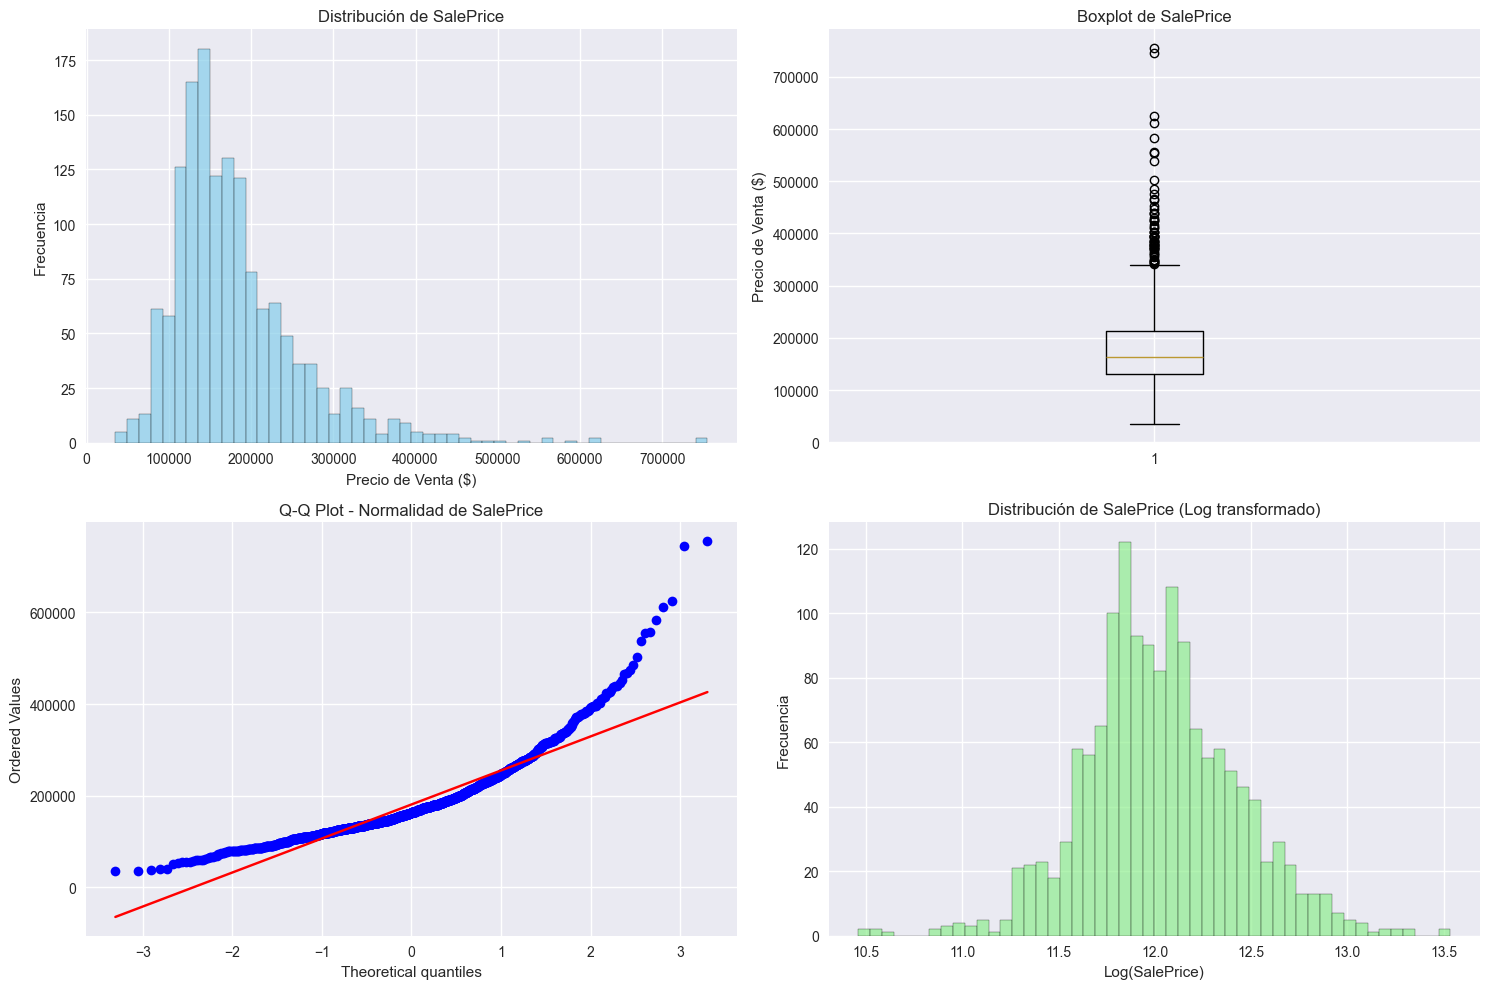

📊 Estadísticas de SalePrice:
Skewness: 1.883
Kurtosis: 6.536
Skewness (log): 0.121
Kurtosis (log): 0.810


In [4]:
# Visualización de la distribución de SalePrice
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma
axes[0,0].hist(df_train['SalePrice'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribución de SalePrice')
axes[0,0].set_xlabel('Precio de Venta ($)')
axes[0,0].set_ylabel('Frecuencia')

# Boxplot
axes[0,1].boxplot(df_train['SalePrice'])
axes[0,1].set_title('Boxplot de SalePrice')
axes[0,1].set_ylabel('Precio de Venta ($)')

# Q-Q plot para normalidad
from scipy import stats
stats.probplot(df_train['SalePrice'], dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot - Normalidad de SalePrice')

# Log transformación
log_saleprice = np.log1p(df_train['SalePrice'])
axes[1,1].hist(log_saleprice, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1,1].set_title('Distribución de SalePrice (Log transformado)')
axes[1,1].set_xlabel('Log(SalePrice)')
axes[1,1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("📊 Estadísticas de SalePrice:")
print(f"Skewness: {df_train['SalePrice'].skew():.3f}")
print(f"Kurtosis: {df_train['SalePrice'].kurtosis():.3f}")
print(f"Skewness (log): {log_saleprice.skew():.3f}")
print(f"Kurtosis (log): {log_saleprice.kurtosis():.3f}")


🔗 TOP 15 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE:
 1. OverallQual         :  0.791
 2. GrLivArea           :  0.709
 3. GarageCars          :  0.640
 4. GarageArea          :  0.623
 5. TotalBsmtSF         :  0.614
 6. 1stFlrSF            :  0.606
 7. FullBath            :  0.561
 8. TotRmsAbvGrd        :  0.534
 9. YearBuilt           :  0.523
10. YearRemodAdd        :  0.507
11. GarageYrBlt         :  0.486
12. MasVnrArea          :  0.477
13. Fireplaces          :  0.467
14. BsmtFinSF1          :  0.386
15. LotFrontage         :  0.352

🔗 TOP 15 VARIABLES MENOS CORRELACIONADAS CON SALEPRICE:
 1. BsmtUnfSF           :  0.214
 2. BedroomAbvGr        :  0.168
 3. ScreenPorch         :  0.111
 4. PoolArea            :  0.092
 5. MoSold              :  0.046
 6. 3SsnPorch           :  0.045
 7. BsmtFinSF2          : -0.011
 8. BsmtHalfBath        : -0.017
 9. MiscVal             : -0.021
10. LowQualFinSF        : -0.026
11. YrSold              : -0.029
12. OverallCond         : -0.07

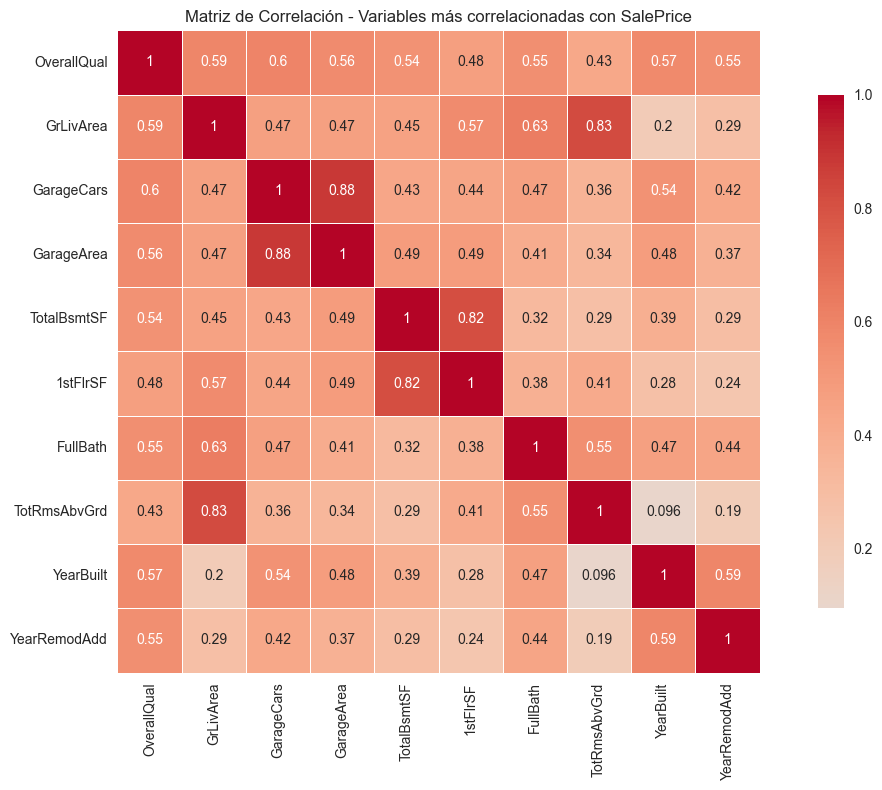

In [5]:
# Análisis de correlaciones con variables numéricas
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('Id')  # Remover ID que no es relevante

# Calcular correlaciones con SalePrice
correlations = df_train[numeric_features].corr()['SalePrice'].sort_values(ascending=False)

print("🔗 TOP 15 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE:")
print("=" * 60)
for i, (feature, corr) in enumerate(correlations.head(16).items()):
    if feature != 'SalePrice':
        print(f"{i:2d}. {feature:20s}: {corr:6.3f}")

print("\n🔗 TOP 15 VARIABLES MENOS CORRELACIONADAS CON SALEPRICE:")
print("=" * 60)
for i, (feature, corr) in enumerate(correlations.tail(15).items()):
    print(f"{i+1:2d}. {feature:20s}: {corr:6.3f}")

# Visualizar las correlaciones más altas
plt.figure(figsize=(12, 8))
top_corr_features = correlations.head(11).index[1:]  # Excluir SalePrice
corr_matrix = df_train[top_corr_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación - Variables más correlacionadas con SalePrice')
plt.tight_layout()
plt.show()


📊 ANÁLISIS DE VARIABLES CATEGÓRICAS:
Total de variables categóricas: 43
Variables: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

🔍 INFORMACIÓN DETALLADA POR VARIABLE CATEGÓRICA:
MSZoning            :   5 valores únicos,   0 faltantes
                      Top valores: {'RL': 1151, 'RM': 218, 'FV': 65}

Street              :   2 valores únicos,   0 faltantes
                      Top valores: {'Pave': 1454, 'Grvl': 6}

Alley               :   2 valores únicos, 1

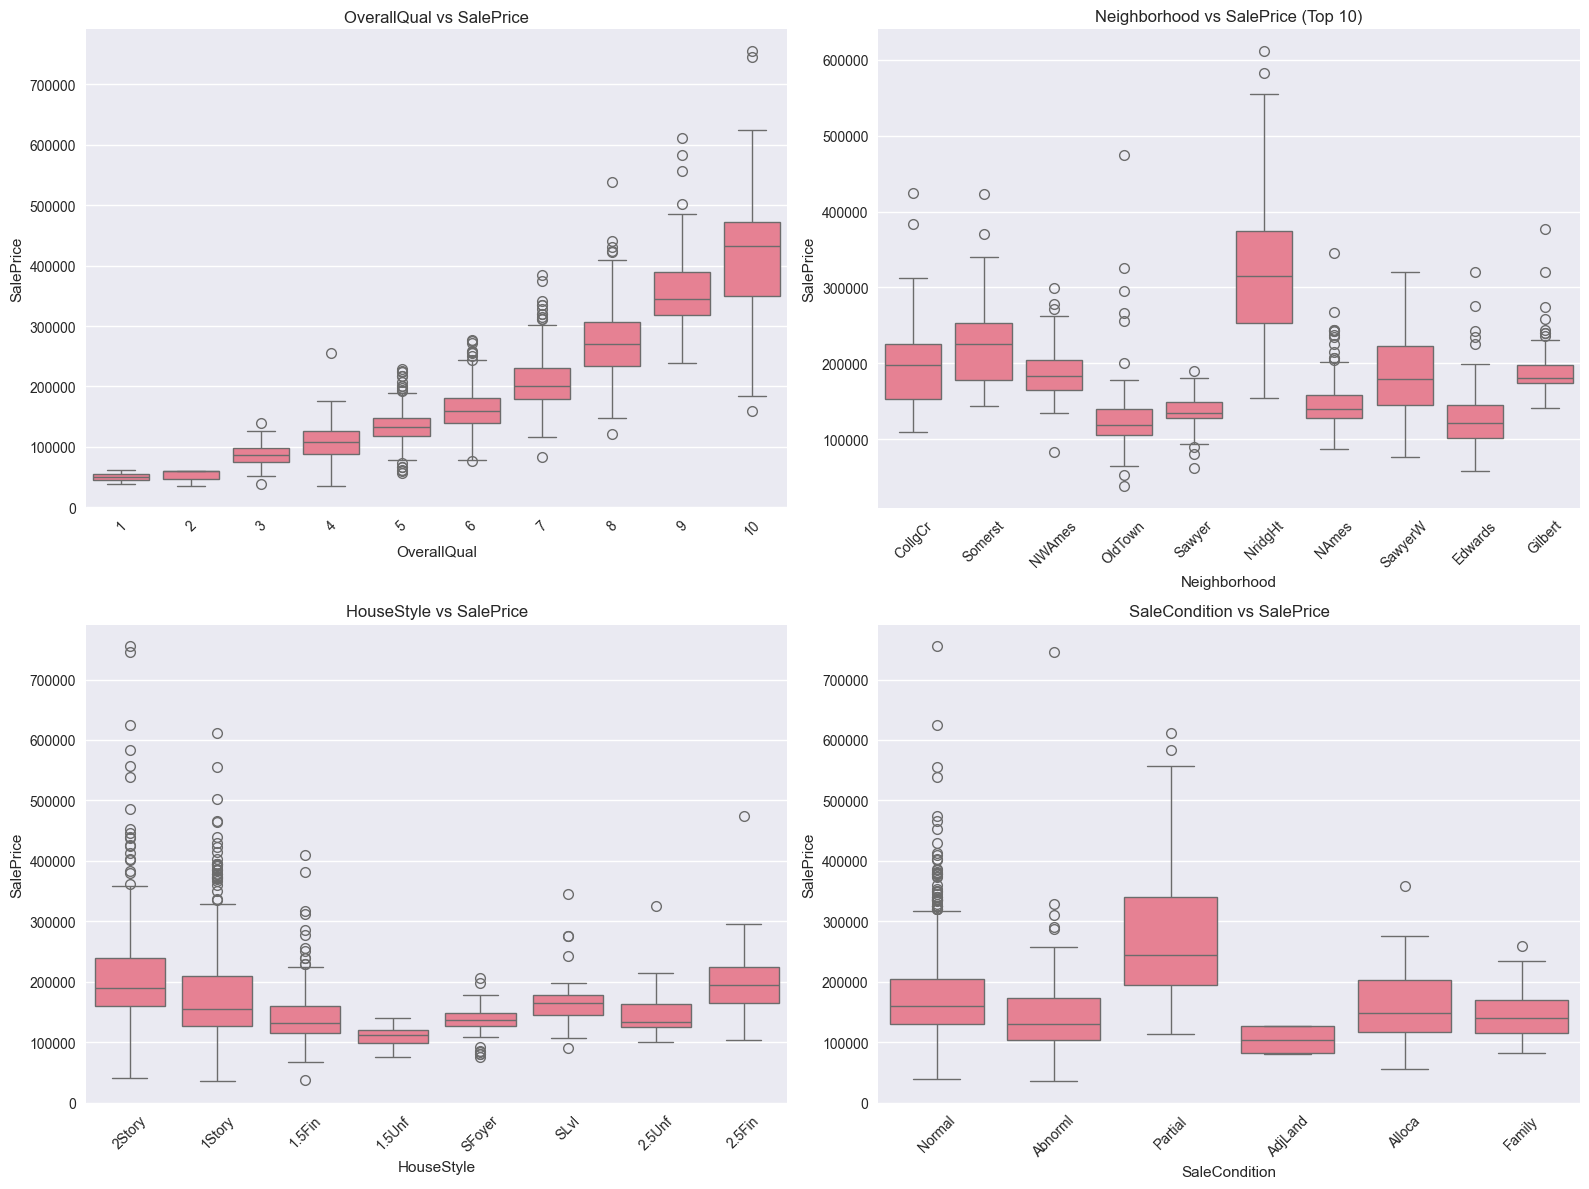

In [6]:
# Análisis de variables categóricas
categorical_features = df_train.select_dtypes(include=['object']).columns.tolist()

print(f"📊 ANÁLISIS DE VARIABLES CATEGÓRICAS:")
print(f"Total de variables categóricas: {len(categorical_features)}")
print(f"Variables: {categorical_features}")

# Análisis de cada variable categórica
print("\n🔍 INFORMACIÓN DETALLADA POR VARIABLE CATEGÓRICA:")
print("=" * 80)

for feature in categorical_features[:10]:  # Mostrar las primeras 10
    unique_values = df_train[feature].nunique()
    missing_values = df_train[feature].isnull().sum()
    print(f"{feature:20s}: {unique_values:3d} valores únicos, {missing_values:3d} faltantes")
    
    # Mostrar los valores más frecuentes
    top_values = df_train[feature].value_counts().head(3)
    print(f"{'':20s}  Top valores: {dict(top_values)}")
    print()

# Visualización de algunas variables categóricas importantes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# OverallQual vs SalePrice
sns.boxplot(data=df_train, x='OverallQual', y='SalePrice', ax=axes[0,0])
axes[0,0].set_title('OverallQual vs SalePrice')
axes[0,0].tick_params(axis='x', rotation=45)

# Neighborhood vs SalePrice (top 10)
top_neighborhoods = df_train['Neighborhood'].value_counts().head(10).index
neighborhood_data = df_train[df_train['Neighborhood'].isin(top_neighborhoods)]
sns.boxplot(data=neighborhood_data, x='Neighborhood', y='SalePrice', ax=axes[0,1])
axes[0,1].set_title('Neighborhood vs SalePrice (Top 10)')
axes[0,1].tick_params(axis='x', rotation=45)

# HouseStyle vs SalePrice
sns.boxplot(data=df_train, x='HouseStyle', y='SalePrice', ax=axes[1,0])
axes[1,0].set_title('HouseStyle vs SalePrice')
axes[1,0].tick_params(axis='x', rotation=45)

# SaleCondition vs SalePrice
sns.boxplot(data=df_train, x='SaleCondition', y='SalePrice', ax=axes[1,1])
axes[1,1].set_title('SaleCondition vs SalePrice')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Paso 3: Limpieza de datos

Ahora vamos a:
- Identificar y manejar valores faltantes
- Detectar y tratar valores atípicos
- Agrupar categorías poco frecuentes


ANÁLISIS DE VALORES FALTANTES:
Columnas con valores faltantes: 19
                   Columna  Valores_faltantes  Porcentaje
PoolQC              PoolQC               1453   99.520548
MiscFeature    MiscFeature               1406   96.301370
Alley                Alley               1369   93.767123
Fence                Fence               1179   80.753425
FireplaceQu    FireplaceQu                690   47.260274
LotFrontage    LotFrontage                259   17.739726
GarageYrBlt    GarageYrBlt                 81    5.547945
GarageCond      GarageCond                 81    5.547945
GarageType      GarageType                 81    5.547945
GarageFinish  GarageFinish                 81    5.547945
GarageQual      GarageQual                 81    5.547945
BsmtFinType2  BsmtFinType2                 38    2.602740
BsmtExposure  BsmtExposure                 38    2.602740
BsmtQual          BsmtQual                 37    2.534247
BsmtCond          BsmtCond                 37    2.534247
BsmtFi

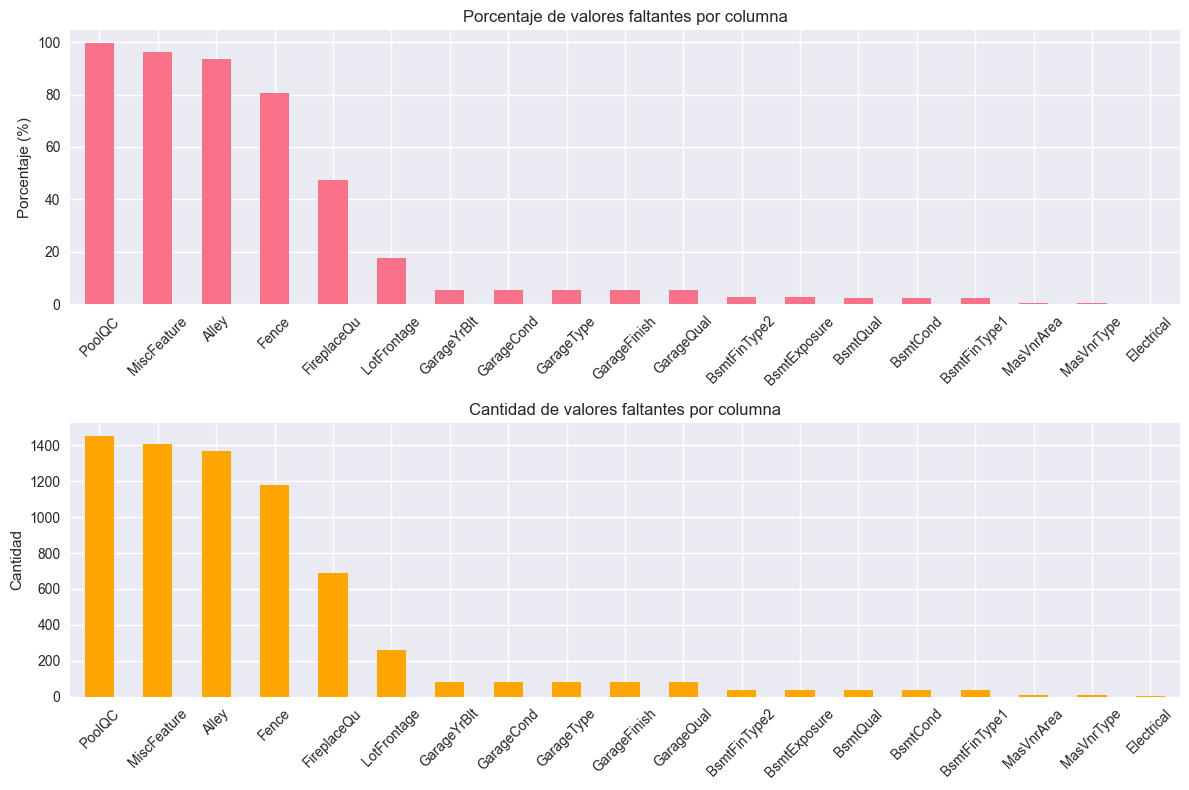

In [7]:
# Análisis detallado de valores faltantes
print("ANÁLISIS DE VALORES FALTANTES:")
print("=" * 50)

missing_analysis = pd.DataFrame({
    'Columna': df_train.columns,
    'Valores_faltantes': df_train.isnull().sum(),
    'Porcentaje': (df_train.isnull().sum() / len(df_train)) * 100
}).sort_values('Valores_faltantes', ascending=False)

# Mostrar solo columnas con valores faltantes
missing_with_values = missing_analysis[missing_analysis['Valores_faltantes'] > 0]
print(f"Columnas con valores faltantes: {len(missing_with_values)}")
print(missing_with_values)

# Visualización de valores faltantes
plt.figure(figsize=(12, 8))
if len(missing_with_values) > 0:
    plt.subplot(2, 1, 1)
    missing_with_values['Porcentaje'].plot(kind='bar')
    plt.title('Porcentaje de valores faltantes por columna')
    plt.ylabel('Porcentaje (%)')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 1, 2)
    missing_with_values['Valores_faltantes'].plot(kind='bar', color='orange')
    plt.title('Cantidad de valores faltantes por columna')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ No hay valores faltantes en el dataset")


In [8]:
# Estrategia de imputación de valores faltantes
print("🔧 ESTRATEGIA DE IMPUTACIÓN:")
print("=" * 40)

# Crear una copia para trabajar
train_clean = df_train.copy()

# 1. Variables categóricas: imputar con 'None' o 'Unknown'
categorical_missing = train_clean.select_dtypes(include=['object']).columns
for col in categorical_missing:
    if train_clean[col].isnull().sum() > 0:
        train_clean[col].fillna('None', inplace=True)
        print(f"✅ {col}: imputado con 'None'")

# 2. Variables numéricas: diferentes estrategias según el tipo
numeric_missing = train_clean.select_dtypes(include=[np.number]).columns
for col in numeric_missing:
    if train_clean[col].isnull().sum() > 0:
        if col in ['LotFrontage']:
            # Para LotFrontage, usar la mediana por Neighborhood
            train_clean[col] = train_clean.groupby('Neighborhood')[col].transform(
                lambda x: x.fillna(x.median())
            )
            print(f"✅ {col}: imputado con mediana por Neighborhood")
        elif col in ['GarageYrBlt', 'MasVnrArea']:
            # Para años, usar 0 (no existe)
            train_clean[col].fillna(0, inplace=True)
            print(f"✅ {col}: imputado con 0")
        else:
            # Para el resto, usar la mediana
            train_clean[col].fillna(train_clean[col].median(), inplace=True)
            print(f"✅ {col}: imputado con mediana")

# Verificar que no queden valores faltantes
remaining_missing = train_clean.isnull().sum().sum()
print(f"\n🎯 Valores faltantes restantes: {remaining_missing}")

if remaining_missing == 0:
    print("✅ ¡Todos los valores faltantes han sido imputados!")
else:
    print("⚠️ Aún quedan valores faltantes por resolver")
    print("Columnas con valores faltantes:")
    missing_cols = train_clean.columns[train_clean.isnull().any()].tolist()
    for col in missing_cols:
        print(f"  - {col}: {train_clean[col].isnull().sum()} valores faltantes")
    
    # Imputar valores faltantes restantes
    print("\n🔧 Imputando valores faltantes restantes...")
    for col in missing_cols:
        if train_clean[col].dtype == 'object':
            train_clean[col].fillna('None', inplace=True)
        else:
            train_clean[col].fillna(train_clean[col].median(), inplace=True)
    
    print(f"✅ Valores faltantes restantes después de imputación: {train_clean.isnull().sum().sum()}")


🔧 ESTRATEGIA DE IMPUTACIÓN:
✅ Alley: imputado con 'None'
✅ MasVnrType: imputado con 'None'
✅ BsmtQual: imputado con 'None'
✅ BsmtCond: imputado con 'None'
✅ BsmtExposure: imputado con 'None'
✅ BsmtFinType1: imputado con 'None'
✅ BsmtFinType2: imputado con 'None'
✅ Electrical: imputado con 'None'
✅ FireplaceQu: imputado con 'None'
✅ GarageType: imputado con 'None'
✅ GarageFinish: imputado con 'None'
✅ GarageQual: imputado con 'None'
✅ GarageCond: imputado con 'None'
✅ PoolQC: imputado con 'None'
✅ Fence: imputado con 'None'
✅ MiscFeature: imputado con 'None'
✅ LotFrontage: imputado con mediana por Neighborhood
✅ MasVnrArea: imputado con 0
✅ GarageYrBlt: imputado con 0

🎯 Valores faltantes restantes: 0
✅ ¡Todos los valores faltantes han sido imputados!


🎯 DETECCIÓN DE VALORES ATÍPICOS:
SalePrice      :  61 outliers (  4.2%)
GrLivArea      :  31 outliers (  2.1%)
TotalBsmtSF    :  61 outliers (  4.2%)
LotArea        :  69 outliers (  4.7%)
GarageArea     :  21 outliers (  1.4%)


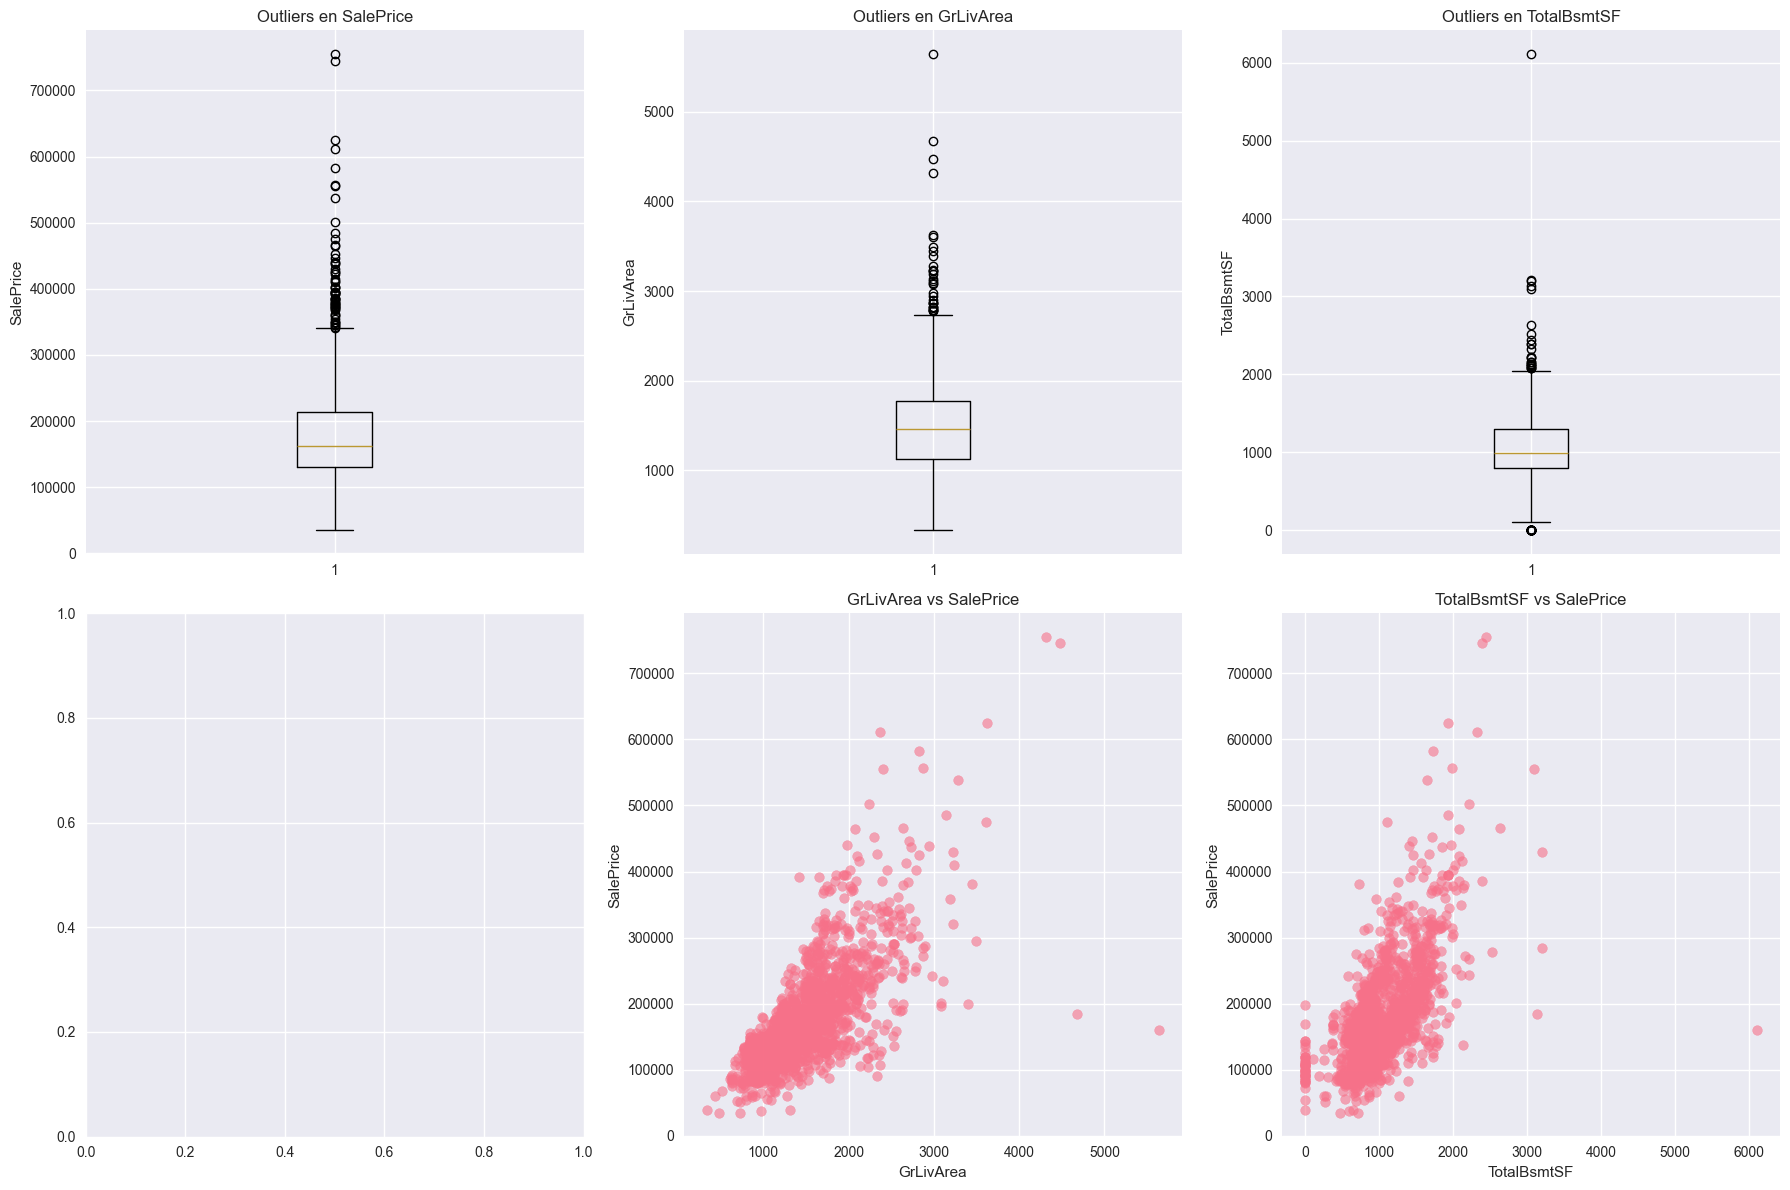


🤔 DECISIÓN SOBRE OUTLIERS:
Se recomienda eliminar solo outliers extremos que puedan ser errores de datos
Por ejemplo, casas con GrLivArea > 4000 y SalePrice < 300000


In [9]:
# Detección y tratamiento de valores atípicos
print("🎯 DETECCIÓN DE VALORES ATÍPICOS:")
print("=" * 40)

# Usar IQR para detectar outliers en variables numéricas importantes
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Variables importantes para analizar outliers
important_numeric = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea']

outlier_summary = []
for col in important_numeric:
    outliers, lower, upper = detect_outliers_iqr(train_clean, col)
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(train_clean)) * 100
    outlier_summary.append({
        'Variable': col,
        'Outliers': outlier_count,
        'Porcentaje': outlier_percent,
        'Límite_inferior': lower,
        'Límite_superior': upper
    })
    print(f"{col:15s}: {outlier_count:3d} outliers ({outlier_percent:5.1f}%)")

# Visualización de outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(important_numeric):
    if i < 3:  # Solo usar las primeras 3 posiciones para boxplots
        # Boxplot
        axes[i].boxplot(train_clean[col])
        axes[i].set_title(f'Outliers en {col}')
        axes[i].set_ylabel(col)
        
        # Scatter plot para SalePrice vs otras variables
        if col != 'SalePrice' and i < 3:
            axes[i+3].scatter(train_clean[col], train_clean['SalePrice'], alpha=0.6)
            axes[i+3].set_xlabel(col)
            axes[i+3].set_ylabel('SalePrice')
            axes[i+3].set_title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()

# Decidir si eliminar outliers extremos
print("\n🤔 DECISIÓN SOBRE OUTLIERS:")
print("Se recomienda eliminar solo outliers extremos que puedan ser errores de datos")
print("Por ejemplo, casas con GrLivArea > 4000 y SalePrice < 300000")


In [10]:
# Eliminar outliers extremos (solo los más obvios)
print("🗑️ ELIMINACIÓN DE OUTLIERS EXTREMOS:")
print("=" * 40)

# Identificar outliers extremos que parecen errores de datos
extreme_outliers = train_clean[
    (train_clean['GrLivArea'] > 4000) & (train_clean['SalePrice'] < 300000)
]

print(f"Outliers extremos identificados: {len(extreme_outliers)}")
if len(extreme_outliers) > 0:
    print("Detalles de los outliers extremos:")
    print(extreme_outliers[['Id', 'GrLivArea', 'SalePrice']])
    
    # Eliminar estos outliers
    train_clean = train_clean.drop(extreme_outliers.index)
    print(f"✅ Eliminados {len(extreme_outliers)} outliers extremos")
    print(f"Dataset final: {train_clean.shape}")
else:
    print("✅ No se encontraron outliers extremos para eliminar")

# Agrupar categorías poco frecuentes en variables categóricas
print("\n📊 AGRUPACIÓN DE CATEGORÍAS POCO FRECUENTES:")
print("=" * 50)

for col in categorical_features:
    value_counts = train_clean[col].value_counts()
    low_freq_categories = value_counts[value_counts < 10].index
    
    if len(low_freq_categories) > 0:
        print(f"{col}: {len(low_freq_categories)} categorías con < 10 observaciones")
        # Agrupar en 'Other'
        train_clean[col] = train_clean[col].replace(low_freq_categories, 'Other')
        print(f"  → Agrupadas en 'Other'")

print("\n✅ Limpieza de datos completada!")
print(f"Dataset final: {train_clean.shape}")


🗑️ ELIMINACIÓN DE OUTLIERS EXTREMOS:
Outliers extremos identificados: 2
Detalles de los outliers extremos:
        Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000
✅ Eliminados 2 outliers extremos
Dataset final: (1458, 81)

📊 AGRUPACIÓN DE CATEGORÍAS POCO FRECUENTES:
Street: 1 categorías con < 10 observaciones
  → Agrupadas en 'Other'
LotShape: 1 categorías con < 10 observaciones
  → Agrupadas en 'Other'
Utilities: 1 categorías con < 10 observaciones
  → Agrupadas en 'Other'
LotConfig: 1 categorías con < 10 observaciones
  → Agrupadas en 'Other'
Neighborhood: 2 categorías con < 10 observaciones
  → Agrupadas en 'Other'
Condition1: 3 categorías con < 10 observaciones
  → Agrupadas en 'Other'
Condition2: 7 categorías con < 10 observaciones
  → Agrupadas en 'Other'
HouseStyle: 1 categorías con < 10 observaciones
  → Agrupadas en 'Other'
RoofStyle: 2 categorías con < 10 observaciones
  → Agrupadas en 'Other'
RoofMatl: 5 categorías con < 10 observac

## Paso 4: Codificación de variables categóricas

Vamos a convertir las variables categóricas a formato numérico usando:
- **Label Encoding** para variables ordinales (con orden natural)
- **One Hot Encoding** para variables nominales (sin orden)


In [11]:
# Definir variables ordinales (con orden natural)
ordinal_features = {
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtExposure': ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'FireplaceQu': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageFinish': ['None', 'Unf', 'RFn', 'Fin'],
    'GarageQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'PavedDrive': ['N', 'P', 'Y'],
    'PoolQC': ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence': ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'LotShape': ['IR3', 'IR2', 'IR1', 'Reg'],
    'Utilities': ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'LandSlope': ['Sev', 'Mod', 'Gtl'],
    'OverallQual': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'OverallCond': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

print("CODIFICACIÓN DE VARIABLES ORDINALES:")
print("=" * 50)

# Aplicar Label Encoding a variables ordinales
for feature, categories in ordinal_features.items():
    if feature in train_clean.columns:
        # Crear mapeo de categorías a números
        category_mapping = {cat: i for i, cat in enumerate(categories)}
        train_clean[feature] = train_clean[feature].map(category_mapping)
        print(f"✅ {feature}: {len(categories)} categorías codificadas")

# Variables nominales (sin orden natural)
nominal_features = [col for col in categorical_features if col not in ordinal_features.keys()]

print(f"\n🎭 VARIABLES NOMINALES PARA ONE HOT ENCODING:")
print(f"Total: {len(nominal_features)}")
print("Variables:", nominal_features[:10], "..." if len(nominal_features) > 10 else "")

# Aplicar One Hot Encoding a variables nominales
print(f"\n🔄 APLICANDO ONE HOT ENCODING...")
train_encoded = pd.get_dummies(train_clean, columns=nominal_features, prefix=nominal_features)

print(f"✅ Codificación completada!")
print(f"Variables originales: {train_clean.shape[1]}")
print(f"Variables después de codificación: {train_encoded.shape[1]}")
print(f"Nuevas variables creadas: {train_encoded.shape[1] - train_clean.shape[1]}")


CODIFICACIÓN DE VARIABLES ORDINALES:
✅ ExterQual: 5 categorías codificadas
✅ ExterCond: 5 categorías codificadas
✅ BsmtQual: 6 categorías codificadas
✅ BsmtCond: 6 categorías codificadas
✅ BsmtExposure: 5 categorías codificadas
✅ BsmtFinType1: 7 categorías codificadas
✅ BsmtFinType2: 7 categorías codificadas
✅ HeatingQC: 5 categorías codificadas
✅ KitchenQual: 5 categorías codificadas
✅ Functional: 8 categorías codificadas
✅ FireplaceQu: 6 categorías codificadas
✅ GarageFinish: 4 categorías codificadas
✅ GarageQual: 6 categorías codificadas
✅ GarageCond: 6 categorías codificadas
✅ PavedDrive: 3 categorías codificadas
✅ PoolQC: 5 categorías codificadas
✅ Fence: 5 categorías codificadas
✅ LotShape: 4 categorías codificadas
✅ Utilities: 4 categorías codificadas
✅ LandSlope: 3 categorías codificadas
✅ OverallQual: 10 categorías codificadas
✅ OverallCond: 10 categorías codificadas

🎭 VARIABLES NOMINALES PARA ONE HOT ENCODING:
Total: 23
Variables: ['MSZoning', 'Street', 'Alley', 'LandContour

## Paso 5: Escalamiento/Normalización

Aplicaremos normalización a las variables numéricas para que tengan la misma escala.


In [12]:
# Preparar datos para el modelo
print("📊 PREPARACIÓN DE DATOS PARA EL MODELO:")
print("=" * 50)

# Separar características y variable objetivo del dataset de entrenamiento
X_train = train_encoded.drop(['Id', 'SalePrice'], axis=1)
y_train = train_encoded['SalePrice']

print(f"Características de entrenamiento (X_train): {X_train.shape}")
print(f"Variable objetivo de entrenamiento (y_train): {y_train.shape}")

# Aplicar transformación log a la variable objetivo (para normalizar)
y_train_log = np.log1p(y_train)
print(f"Variable objetivo (log): {y_train_log.shape}")

# Aplicar StandardScaler para normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"\n🔧 NORMALIZACIÓN APLICADA:")
print(f"X_train_scaled: {X_train_scaled.shape}")

# Convertir de vuelta a DataFrame para facilitar el trabajo
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Verificación final de valores NaN
print(f"\n🔍 VERIFICACIÓN FINAL DE VALORES NaN:")
print(f"X_train_scaled: {X_train_scaled.isnull().sum().sum()} valores NaN")
print(f"y_train_log: {y_train_log.isnull().sum()} valores NaN")

# Si hay valores NaN, imputarlos
if X_train_scaled.isnull().sum().sum() > 0:
    print("⚠️ Imputando valores NaN en X_train_scaled...")
    X_train_scaled = X_train_scaled.fillna(X_train_scaled.median())

if y_train_log.isnull().sum() > 0:
    print("⚠️ Imputando valores NaN en y_train_log...")
    y_train_log = y_train_log.fillna(y_train_log.median())

print("✅ Datos de entrenamiento preparados y normalizados!")
print("📝 Nota: Los datos de test se procesarán por separado para las predicciones finales")


📊 PREPARACIÓN DE DATOS PARA EL MODELO:
Características de entrenamiento (X_train): (1458, 189)
Variable objetivo de entrenamiento (y_train): (1458,)
Variable objetivo (log): (1458,)

🔧 NORMALIZACIÓN APLICADA:
X_train_scaled: (1458, 189)

🔍 VERIFICACIÓN FINAL DE VALORES NaN:
X_train_scaled: 53 valores NaN
y_train_log: 0 valores NaN
⚠️ Imputando valores NaN en X_train_scaled...
✅ Datos de entrenamiento preparados y normalizados!
📝 Nota: Los datos de test se procesarán por separado para las predicciones finales


## Paso 6: Selección de variables relevantes

Vamos a seleccionar las variables más importantes usando correlaciones y análisis de importancia.


🎯 SELECCIÓN DE VARIABLES RELEVANTES:
TOP 20 VARIABLES MÁS CORRELACIONADAS:
 1. OverallQual                   : 0.8214
 2. GrLivArea                     : 0.7252
 3. ExterQual                     : 0.6822
 4. GarageCars                    : 0.6810
 5. KitchenQual                   : 0.6700
 6. GarageArea                    : 0.6561
 7. TotalBsmtSF                   : 0.6476
 8. 1stFlrSF                      : 0.6205
 9. BsmtQual                      : 0.6169
10. GarageFinish                  : 0.6056
11. FullBath                      : 0.5959
12. YearBuilt                     : 0.5870
13. YearRemodAdd                  : 0.5660
14. FireplaceQu                   : 0.5468
15. TotRmsAbvGrd                  : 0.5377
16. Foundation_PConc              : 0.5312
17. Fireplaces                    : 0.4920
18. HeatingQC                     : 0.4724
19. MasVnrArea                    : 0.4306
20. GarageType_Attchd             : 0.4164

📊 VARIABLES SELECCIONADAS (correlación > 0.1):
Total: 108 de 189

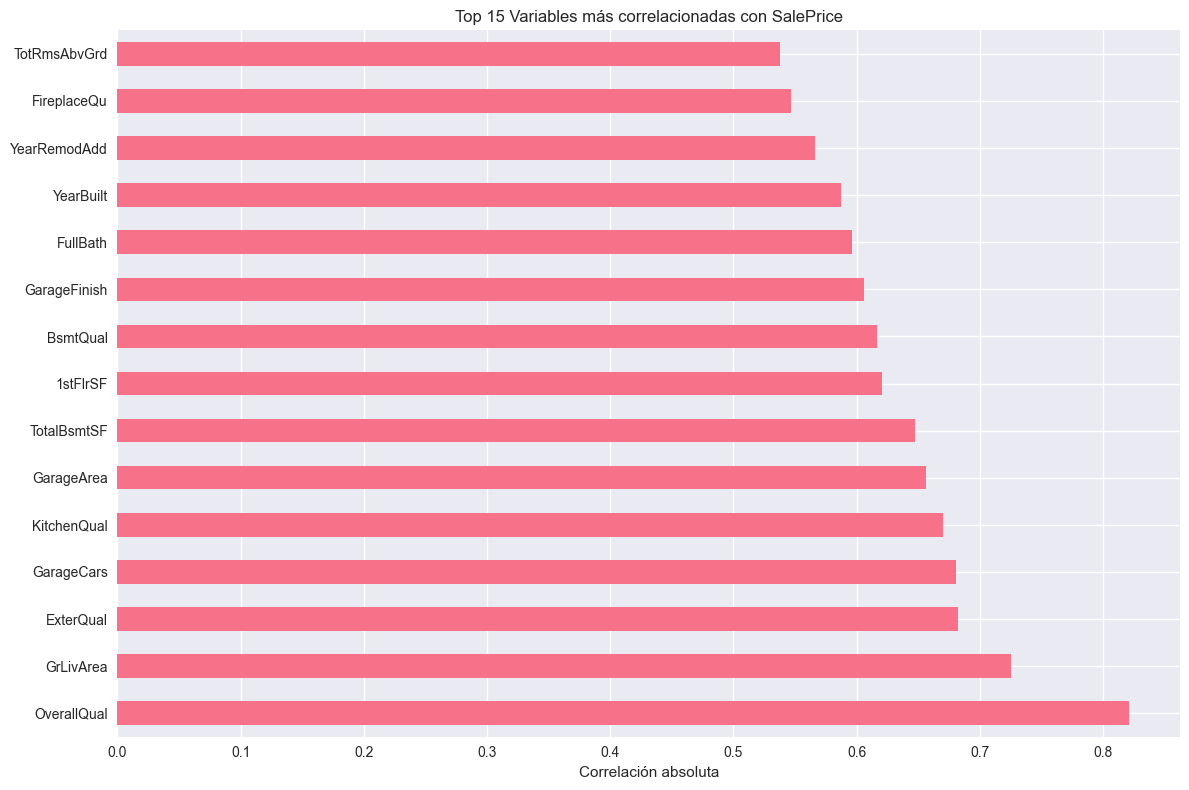

✅ Variables seleccionadas para el modelo!


In [13]:
# Selección de variables usando correlaciones
print("🎯 SELECCIÓN DE VARIABLES RELEVANTES:")
print("=" * 50)

# Calcular correlaciones con la variable objetivo
correlations_with_target = X_train.corrwith(y_train_log).abs().sort_values(ascending=False)

print("TOP 20 VARIABLES MÁS CORRELACIONADAS:")
print("=" * 40)
top_features = correlations_with_target.head(20)
for i, (feature, corr) in enumerate(top_features.items(), 1):
    print(f"{i:2d}. {feature:30s}: {corr:.4f}")

# Seleccionar variables con correlación > 0.1
selected_features = correlations_with_target[correlations_with_target > 0.1].index.tolist()
print(f"\n📊 VARIABLES SELECCIONADAS (correlación > 0.1):")
print(f"Total: {len(selected_features)} de {len(X_train.columns)}")

# Crear dataset con variables seleccionadas
X_train_selected = X_train_scaled[selected_features]

print(f"X_train_selected: {X_train_selected.shape}")

# Verificar que no hay valores NaN en las variables seleccionadas
print(f"\n🔍 VERIFICACIÓN DE VALORES NaN EN VARIABLES SELECCIONADAS:")
print(f"Valores NaN en X_train_selected: {X_train_selected.isnull().sum().sum()}")

# Si hay valores NaN, imputarlos
if X_train_selected.isnull().sum().sum() > 0:
    print("⚠️ Imputando valores NaN en X_train_selected...")
    X_train_selected = X_train_selected.fillna(X_train_selected.median())
    print(f"Valores NaN después de imputación: {X_train_selected.isnull().sum().sum()}")

# Visualizar las correlaciones más altas
plt.figure(figsize=(12, 8))
top_15_features = correlations_with_target.head(15)
top_15_features.plot(kind='barh')
plt.title('Top 15 Variables más correlacionadas con SalePrice')
plt.xlabel('Correlación absoluta')
plt.tight_layout()
plt.show()

print("✅ Variables seleccionadas para el modelo!")


In [14]:
# DIAGNÓSTICO DETALLADO DE VALORES NaN
print("🔍 DIAGNÓSTICO DETALLADO DE VALORES NaN:")
print("=" * 50)

# Verificar cada paso del procesamiento
print("1. Verificando train_clean:")
print(f"   Valores NaN: {train_clean.isnull().sum().sum()}")
if train_clean.isnull().sum().sum() > 0:
    print("   Columnas con NaN:")
    for col in train_clean.columns[train_clean.isnull().any()]:
        print(f"     - {col}: {train_clean[col].isnull().sum()}")

print("\n2. Verificando train_encoded:")
print(f"   Valores NaN: {train_encoded.isnull().sum().sum()}")
if train_encoded.isnull().sum().sum() > 0:
    print("   Columnas con NaN:")
    for col in train_encoded.columns[train_encoded.isnull().any()]:
        print(f"     - {col}: {train_encoded[col].isnull().sum()}")

print("\n3. Verificando X_train:")
print(f"   Valores NaN: {X_train.isnull().sum().sum()}")
if X_train.isnull().sum().sum() > 0:
    print("   Columnas con NaN:")
    for col in X_train.columns[X_train.isnull().any()]:
        print(f"     - {col}: {X_train[col].isnull().sum()}")

print("\n4. Verificando y_train_log:")
print(f"   Valores NaN: {y_train_log.isnull().sum()}")

print("\n5. Verificando X_train_scaled:")
print(f"   Valores NaN: {X_train_scaled.isnull().sum().sum()}")
if X_train_scaled.isnull().sum().sum() > 0:
    print("   Columnas con NaN:")
    for col in X_train_scaled.columns[X_train_scaled.isnull().any()]:
        print(f"     - {col}: {X_train_scaled[col].isnull().sum()}")

print("\n6. Verificando X_train_selected:")
print(f"   Valores NaN: {X_train_selected.isnull().sum().sum()}")
if X_train_selected.isnull().sum().sum() > 0:
    print("   Columnas con NaN:")
    for col in X_train_selected.columns[X_train_selected.isnull().any()]:
        print(f"     - {col}: {X_train_selected[col].isnull().sum()}")

# Imputar valores NaN si los hay
if X_train_selected.isnull().sum().sum() > 0:
    print("\n🔧 IMPUTANDO VALORES NaN EN X_train_selected:")
    X_train_selected = X_train_selected.fillna(X_train_selected.median())
    print(f"   Valores NaN después de imputación: {X_train_selected.isnull().sum().sum()}")

if y_train_log.isnull().sum() > 0:
    print("\n🔧 IMPUTANDO VALORES NaN EN y_train_log:")
    y_train_log = y_train_log.fillna(y_train_log.median())
    print(f"   Valores NaN después de imputación: {y_train_log.isnull().sum()}")

print("\n✅ Diagnóstico completado!")


🔍 DIAGNÓSTICO DETALLADO DE VALORES NaN:
1. Verificando train_clean:
   Valores NaN: 53
   Columnas con NaN:
     - LotShape: 9
     - Utilities: 1
     - ExterCond: 4
     - BsmtCond: 2
     - HeatingQC: 1
     - Functional: 6
     - GarageQual: 6
     - GarageCond: 18
     - PoolQC: 6

2. Verificando train_encoded:
   Valores NaN: 53
   Columnas con NaN:
     - LotShape: 9
     - Utilities: 1
     - ExterCond: 4
     - BsmtCond: 2
     - HeatingQC: 1
     - Functional: 6
     - GarageQual: 6
     - GarageCond: 18
     - PoolQC: 6

3. Verificando X_train:
   Valores NaN: 53
   Columnas con NaN:
     - LotShape: 9
     - Utilities: 1
     - ExterCond: 4
     - BsmtCond: 2
     - HeatingQC: 1
     - Functional: 6
     - GarageQual: 6
     - GarageCond: 18
     - PoolQC: 6

4. Verificando y_train_log:
   Valores NaN: 0

5. Verificando X_train_scaled:
   Valores NaN: 0

6. Verificando X_train_selected:
   Valores NaN: 0

✅ Diagnóstico completado!


## Paso 7: Construcción del modelo

Vamos a construir y entrenar un modelo de **Regresión Lineal Múltiple** como se especifica en el examen.


In [15]:
# Construcción y entrenamiento del modelo de Regresión Lineal Múltiple
print("🤖 CONSTRUCCIÓN DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE:")
print("=" * 60)

# Verificación final antes del entrenamiento
print("🔍 VERIFICACIÓN FINAL ANTES DEL ENTRENAMIENTO:")
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"y_train_log shape: {y_train_log.shape}")
print(f"Valores NaN en X_train_selected: {X_train_selected.isnull().sum().sum()}")
print(f"Valores NaN en y_train_log: {y_train_log.isnull().sum()}")

# Crear y entrenar el modelo
print("\n🚀 ENTRENANDO EL MODELO...")
model = LinearRegression()
model.fit(X_train_selected, y_train_log)

print(f"✅ Modelo entrenado exitosamente!")
print(f"Características utilizadas: {X_train_selected.shape[1]}")
print(f"Muestras de entrenamiento: {X_train_selected.shape[0]}")

# Hacer predicciones en el conjunto de entrenamiento
y_train_pred_log = model.predict(X_train_selected)

print(f"\n📊 PREDICCIONES GENERADAS:")
print(f"Predicciones entrenamiento: {len(y_train_pred_log)}")

# Convertir predicciones de vuelta a escala original (inversa de log)
y_train_pred_original = np.expm1(y_train_pred_log)
y_train_original = np.expm1(y_train_log)

print(f"✅ Predicciones convertidas a escala original")

# Mostrar algunas predicciones de ejemplo
print(f"\n🔍 EJEMPLO DE PREDICCIONES (primeras 5):")
print("=" * 50)
comparison_df = pd.DataFrame({
    'Real': y_train_original[:5],
    'Predicho': y_train_pred_original[:5],
    'Error': y_train_original[:5] - y_train_pred_original[:5]
})
print(comparison_df)


🤖 CONSTRUCCIÓN DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE:
🔍 VERIFICACIÓN FINAL ANTES DEL ENTRENAMIENTO:
X_train_selected shape: (1458, 108)
y_train_log shape: (1458,)
Valores NaN en X_train_selected: 0
Valores NaN en y_train_log: 0

🚀 ENTRENANDO EL MODELO...
✅ Modelo entrenado exitosamente!
Características utilizadas: 108
Muestras de entrenamiento: 1458

📊 PREDICCIONES GENERADAS:
Predicciones entrenamiento: 1458
✅ Predicciones convertidas a escala original

🔍 EJEMPLO DE PREDICCIONES (primeras 5):
       Real       Predicho         Error
0  208500.0  204179.850901   4320.149099
1  181500.0  173688.336121   7811.663879
2  223500.0  213931.600620   9568.399380
3  140000.0  154685.757056 -14685.757056
4  250000.0  293374.055650 -43374.055650


## Paso 8: Evaluación del modelo

Vamos a evaluar el modelo usando las métricas especificadas en el examen:
- **RMSE (Root Mean Squared Error)**
- **MAE (Mean Absolute Error)**  
- **R² (Coeficiente de determinación)**
- **Validación cruzada**


📊 EVALUACIÓN DEL MODELO:
🎯 MÉTRICAS DE RENDIMIENTO (ENTRENAMIENTO):
RMSE: $19,315.28
MAE:  $13,378.45
R²:   0.9409

🔄 VALIDACIÓN CRUZADA (5 folds):
R² scores: [0.90774716 0.91262249 0.89729996 0.9074341  0.89106023]
R² promedio: 0.9032 (+/- 0.0157)


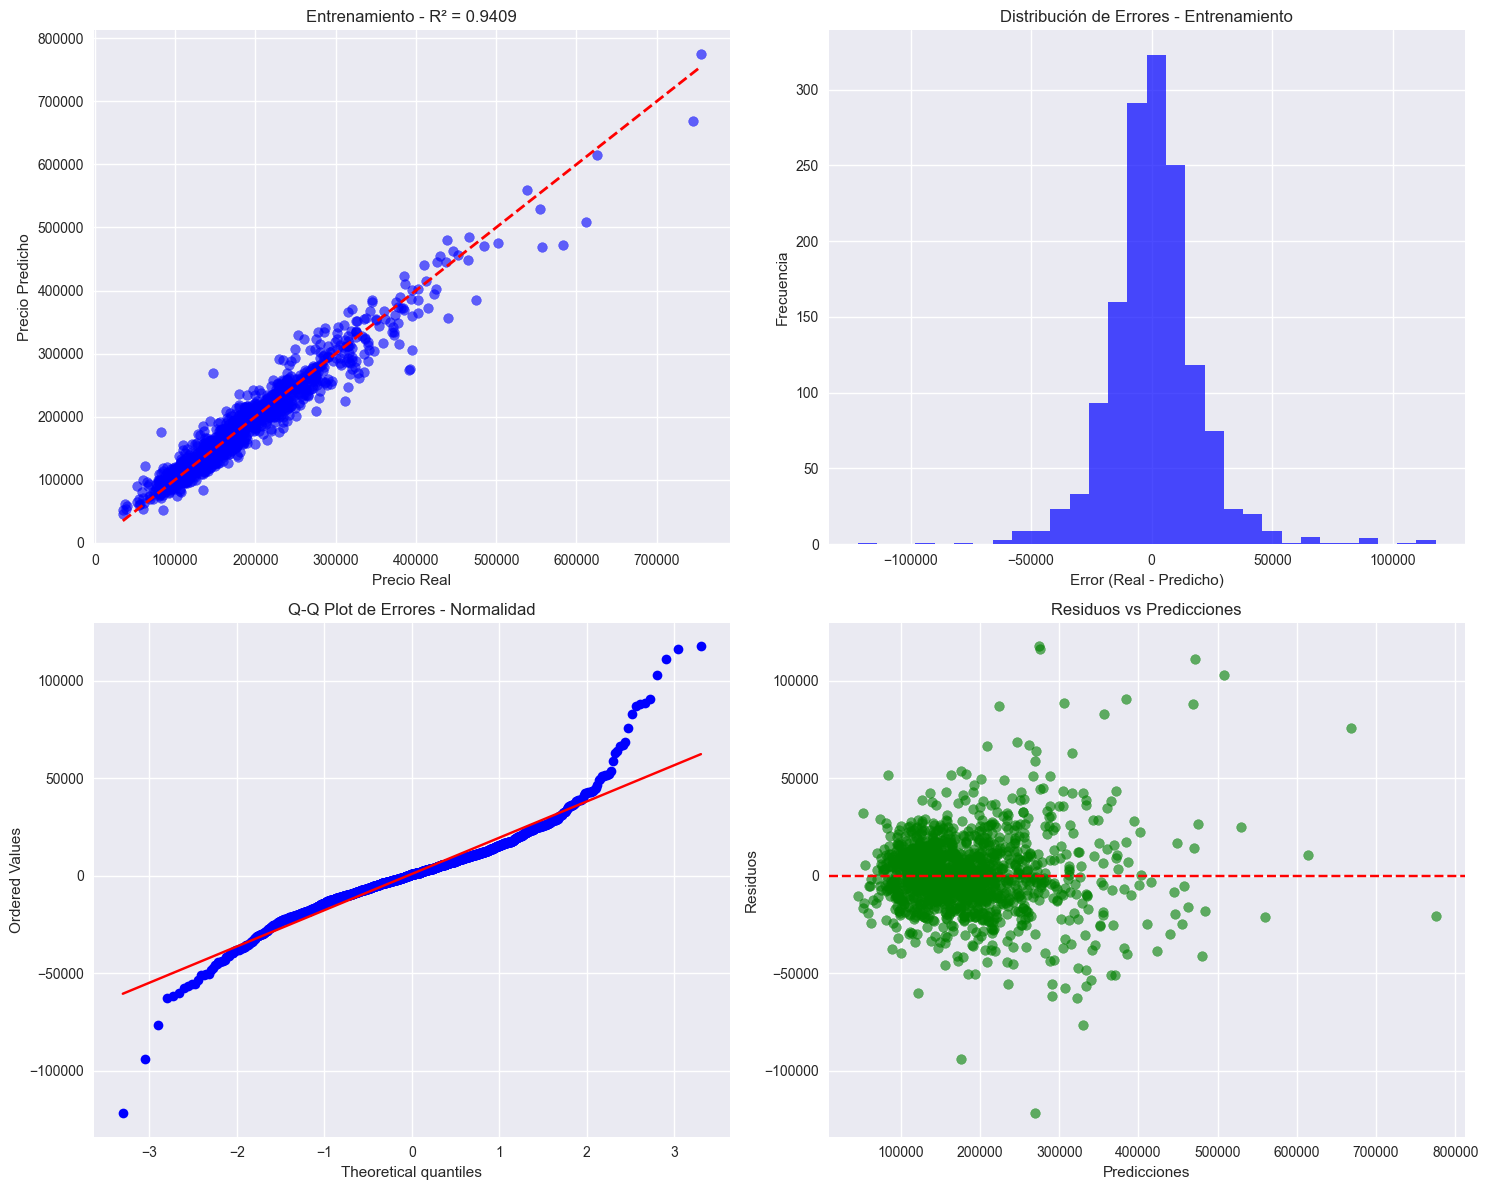


✅ Evaluación completada!
El modelo explica el 94.1% de la varianza en los datos de entrenamiento


In [16]:
# Evaluación del modelo
print("📊 EVALUACIÓN DEL MODELO:")
print("=" * 40)

# Calcular métricas para entrenamiento
train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
train_mae = mean_absolute_error(y_train_original, y_train_pred_original)
train_r2 = r2_score(y_train_original, y_train_pred_original)

print("🎯 MÉTRICAS DE RENDIMIENTO (ENTRENAMIENTO):")
print("=" * 40)
print(f"RMSE: ${train_rmse:,.2f}")
print(f"MAE:  ${train_mae:,.2f}")
print(f"R²:   {train_r2:.4f}")

# Validación cruzada
print(f"\n🔄 VALIDACIÓN CRUZADA (5 folds):")
cv_scores = cross_val_score(model, X_train_selected, y_train_log, cv=5, scoring='r2')
print(f"R² scores: {cv_scores}")
print(f"R² promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualización de resultados
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot: Real vs Predicho (Entrenamiento)
axes[0,0].scatter(y_train_original, y_train_pred_original, alpha=0.6, color='blue')
axes[0,0].plot([y_train_original.min(), y_train_original.max()], 
               [y_train_original.min(), y_train_original.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Precio Real')
axes[0,0].set_ylabel('Precio Predicho')
axes[0,0].set_title(f'Entrenamiento - R² = {train_r2:.4f}')

# Histograma de errores (Entrenamiento)
errors_train = y_train_original - y_train_pred_original
axes[0,1].hist(errors_train, bins=30, alpha=0.7, color='blue')
axes[0,1].set_xlabel('Error (Real - Predicho)')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].set_title('Distribución de Errores - Entrenamiento')

# Q-Q plot de errores
from scipy import stats
stats.probplot(errors_train, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot de Errores - Normalidad')

# Residuos vs Predicciones
axes[1,1].scatter(y_train_pred_original, errors_train, alpha=0.6, color='green')
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Predicciones')
axes[1,1].set_ylabel('Residuos')
axes[1,1].set_title('Residuos vs Predicciones')

plt.tight_layout()
plt.show()

print(f"\n✅ Evaluación completada!")
print(f"El modelo explica el {train_r2*100:.1f}% de la varianza en los datos de entrenamiento")


## Paso 9: Interpretación de resultados y generación de predicciones

Ahora vamos a:
- Interpretar los coeficientes del modelo
- Generar predicciones para el dataset de test
- Crear el archivo de predicciones final


🔍 INTERPRETACIÓN DE LOS COEFICIENTES DEL MODELO:
TOP 15 VARIABLES MÁS INFLUYENTES:
 1. GarageYrBlt                   :  -0.2668
 2. GarageType_None               :  -0.2133
 3. OverallQual                   :   0.0732
 4. 2ndFlrSF                      :   0.0611
 5. 1stFlrSF                      :   0.0594
 6. GrLivArea                     :   0.0550
 7. TotalBsmtSF                   :   0.0383
 8. MSZoning_C (all)              :  -0.0338
 9. MasVnrType_None               :   0.0324
10. YearRemodAdd                  :   0.0306
11. MasVnrType_BrkFace            :   0.0271
12. SaleType_New                  :   0.0260
13. GarageQual                    :   0.0256
14. GarageCond                    :   0.0254
15. MasVnrType_Stone              :   0.0245

📊 RESUMEN DEL MODELO:
Intercepto: 12.0239
Variables utilizadas: 108
R² del modelo: 0.9409


<Figure size 1200x800 with 0 Axes>

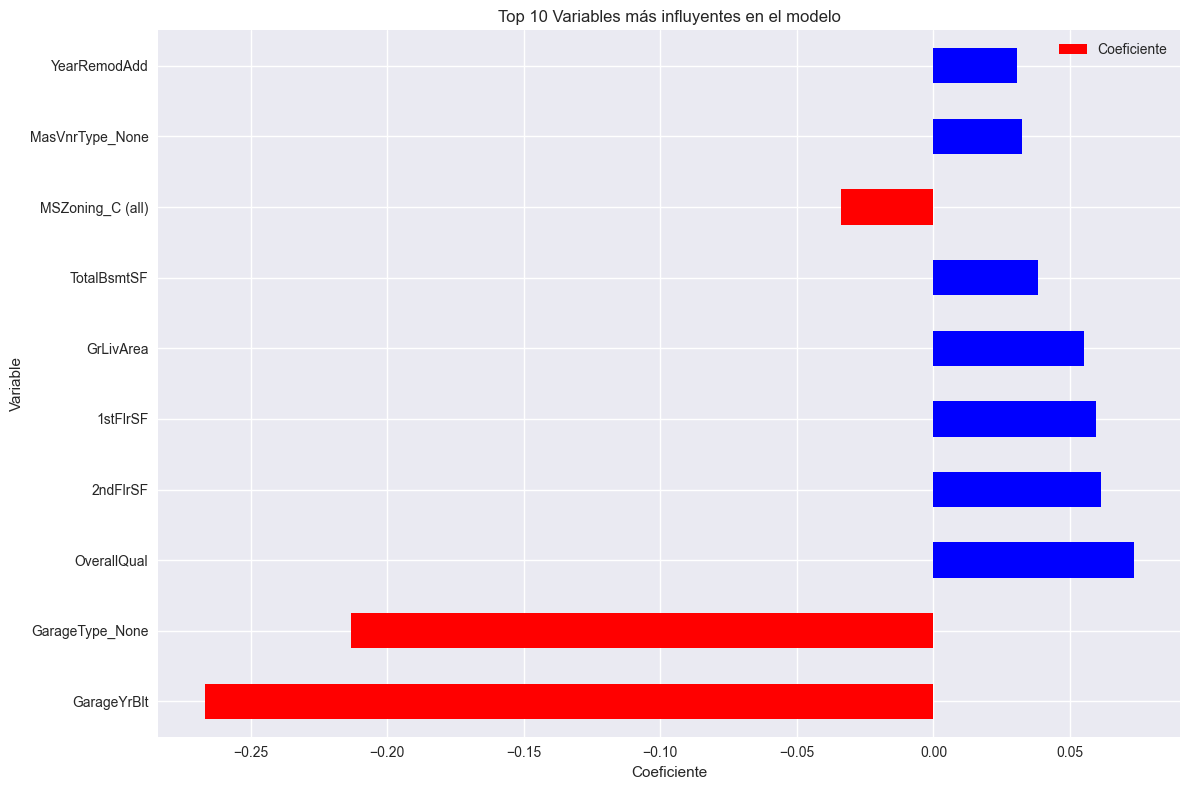

✅ Interpretación completada!


In [17]:
# Interpretación de los coeficientes del modelo
print("🔍 INTERPRETACIÓN DE LOS COEFICIENTES DEL MODELO:")
print("=" * 60)

# Obtener los coeficientes del modelo
coefficients = pd.DataFrame({
    'Variable': selected_features,
    'Coeficiente': model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("TOP 15 VARIABLES MÁS INFLUYENTES:")
print("=" * 40)
for i, (_, row) in enumerate(coefficients.head(15).iterrows(), 1):
    print(f"{i:2d}. {row['Variable']:30s}: {row['Coeficiente']:8.4f}")

print(f"\n📊 RESUMEN DEL MODELO:")
print(f"Intercepto: {model.intercept_:.4f}")
print(f"Variables utilizadas: {len(selected_features)}")
print(f"R² del modelo: {train_r2:.4f}")

# Visualización de los coeficientes más importantes
plt.figure(figsize=(12, 8))
top_10_coeffs = coefficients.head(10)
colors = ['red' if x < 0 else 'blue' for x in top_10_coeffs['Coeficiente']]
top_10_coeffs.plot(x='Variable', y='Coeficiente', kind='barh', color=colors)
plt.title('Top 10 Variables más influyentes en el modelo')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print("✅ Interpretación completada!")


In [18]:
# Procesar el dataset de test y generar predicciones
print("🎯 GENERACIÓN DE PREDICCIONES PARA EL DATASET DE TEST:")
print("=" * 60)

# Aplicar el mismo procesamiento al dataset de test
print("1. Aplicando limpieza de datos al dataset de test...")
df_test_clean = df_test.copy()

# Imputar valores faltantes en test (usando la misma estrategia)
categorical_missing_test = df_test_clean.select_dtypes(include=['object']).columns
for col in categorical_missing_test:
    if df_test_clean[col].isnull().sum() > 0:
        df_test_clean[col].fillna('None', inplace=True)

numeric_missing_test = df_test_clean.select_dtypes(include=[np.number]).columns
for col in numeric_missing_test:
    if df_test_clean[col].isnull().sum() > 0:
        if col in ['LotFrontage']:
            df_test_clean[col] = df_test_clean.groupby('Neighborhood')[col].transform(
                lambda x: x.fillna(x.median())
            )
        elif col in ['GarageYrBlt', 'MasVnrArea']:
            df_test_clean[col].fillna(0, inplace=True)
        else:
            df_test_clean[col].fillna(df_test_clean[col].median(), inplace=True)

print("2. Aplicando codificación de variables categóricas...")
# Aplicar Label Encoding a variables ordinales
for feature, categories in ordinal_features.items():
    if feature in df_test_clean.columns:
        category_mapping = {cat: i for i, cat in enumerate(categories)}
        df_test_clean[feature] = df_test_clean[feature].map(category_mapping)

# Aplicar One Hot Encoding a variables nominales
# Obtener las variables categóricas del dataset de test
categorical_features_test = df_test_clean.select_dtypes(include=['object']).columns.tolist()
nominal_features_test = [col for col in categorical_features_test if col not in ordinal_features.keys()]
df_test_encoded = pd.get_dummies(df_test_clean, columns=nominal_features_test, prefix=nominal_features_test)

print("3. Aplicando normalización...")
# Asegurar que test tenga las mismas columnas que train
X_test = df_test_encoded.drop(['Id'], axis=1)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Aplicar el mismo scaler
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Seleccionar las mismas variables
X_test_selected = X_test_scaled[selected_features]

# Verificar que no hay valores NaN en el dataset de test
print(f"\n🔍 VERIFICACIÓN DE VALORES NaN EN DATASET DE TEST:")
print(f"X_test_selected: {X_test_selected.isnull().sum().sum()} valores NaN")

# Si hay valores NaN, imputarlos
if X_test_selected.isnull().sum().sum() > 0:
    print("⚠️ Imputando valores NaN en X_test_selected...")
    X_test_selected = X_test_selected.fillna(X_test_selected.median())
    print(f"Valores NaN después de imputación: {X_test_selected.isnull().sum().sum()}")

print(f"✅ Dataset de test procesado: {X_test_selected.shape}")
print(f"Variables utilizadas: {len(selected_features)}")


🎯 GENERACIÓN DE PREDICCIONES PARA EL DATASET DE TEST:
1. Aplicando limpieza de datos al dataset de test...
2. Aplicando codificación de variables categóricas...
3. Aplicando normalización...

🔍 VERIFICACIÓN DE VALORES NaN EN DATASET DE TEST:
X_test_selected: 3 valores NaN
⚠️ Imputando valores NaN en X_test_selected...
Valores NaN después de imputación: 0
✅ Dataset de test procesado: (1459, 108)
Variables utilizadas: 108


In [19]:
# Generar predicciones finales
print("4. Generando predicciones...")
y_test_pred_log = model.predict(X_test_selected)

# Convertir predicciones de vuelta a escala original
y_test_pred_original = np.expm1(y_test_pred_log)

print(f"✅ Predicciones generadas: {len(y_test_pred_original)}")

# Crear el archivo de predicciones
predictions_df = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': y_test_pred_original
})

# Guardar el archivo
predictions_df.to_csv('predicciones.csv', index=False)

print(f"\n📁 ARCHIVO DE PREDICCIONES GENERADO:")
print(f"Archivo: predicciones.csv")
print(f"Registros: {len(predictions_df)}")
print(f"Precio promedio predicho: ${y_test_pred_original.mean():,.2f}")
print(f"Precio mínimo predicho: ${y_test_pred_original.min():,.2f}")
print(f"Precio máximo predicho: ${y_test_pred_original.max():,.2f}")

# Mostrar algunas predicciones de ejemplo
print(f"\n🔍 EJEMPLO DE PREDICCIONES (primeras 10):")
print("=" * 50)
print(predictions_df.head(10))

print(f"\n🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!")
print(f"El modelo de Regresión Lineal Múltiple ha sido entrenado y las predicciones han sido generadas.")


4. Generando predicciones...
✅ Predicciones generadas: 1459

📁 ARCHIVO DE PREDICCIONES GENERADO:
Archivo: predicciones.csv
Registros: 1459
Precio promedio predicho: $179,422.91
Precio mínimo predicho: $35,654.72
Precio máximo predicho: $1,649,503.07

🔍 EJEMPLO DE PREDICCIONES (primeras 10):
     Id      SalePrice
0  1461  120063.789991
1  1462  159381.186772
2  1463  178378.223659
3  1464  196123.309308
4  1465  206554.486479
5  1466  172278.831554
6  1467  175154.241199
7  1468  162626.400540
8  1469  196565.636097
9  1470  120305.344390

🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!
El modelo de Regresión Lineal Múltiple ha sido entrenado y las predicciones han sido generadas.
